## Hotel Booking Cancellation Prediction

## Content

Dataset **Hotel Booking Demand** berisi informasi terkait reservasi hotel yang dapat digunakan untuk menganalisis perilaku customer dalam melakukan pemesanan kamar. Dataset ini mencakup berbagai atribut yang menggambarkan karakteristik customer, detail reservasi, serta riwayat booking sebelumnya.

Dataset ini dapat dimanfaatkan untuk membangun model machine learning guna membantu hotel dalam memahami pola booking customer serta memprediksi kemungkinan pembatalan reservasi.

Setiap baris pada dataset merepresentasikan **satu data reservasi hotel**, sedangkan setiap kolom merepresentasikan atribut dari reservasi tersebut. Dataset ini merupakan data reservasi hotel nyata yang telah melalui proses anonymization dimana seluruh informasi personal customer telah dihapus untuk menjaga privasi.

***

## Business Problem Understanding

### Context

Dalam industri perhotelan, pembatalan reservasi merupakan salah satu permasalahan utama yang dapat mempengaruhi kestabilan revenue hotel. Tingginya tingkat pembatalan booking dapat menyebabkan kamar yang sudah dipesan menjadi kosong sehingga hotel kehilangan potensi pendapatan.

Selain itu, booking cancellation juga dapat menyebabkan hotel mengalami kesulitan dalam melakukan perencanaan operasional seperti:

- Revenue forecasting
- Room allocation planning
- Staff allocation
- Marketing strategy

Tanpa adanya sistem prediksi, hotel hanya dapat bereaksi setelah pembatalan terjadi. Oleh karena itu, diperlukan pendekatan berbasis data untuk membantu hotel memprediksi kemungkinan pembatalan reservasi sehingga hotel dapat mengambil tindakan preventif.

***

### Problem Statement

Berdasarkan permasalahan tersebut, maka problem yang ingin diselesaikan adalah:

> Bagaimana memprediksi apakah seorang customer akan membatalkan booking berdasarkan data reservasi yang tersedia.

***

### Goals

Tujuan dari project ini adalah:

1. Membangun model machine learning untuk memprediksi booking cancellation  
2. Mengidentifikasi faktor utama yang mempengaruhi pembatalan booking  
3. Membantu hotel mengurangi cancellation rate melalui data driven insight  
4. Memberikan rekomendasi strategi bisnis berdasarkan hasil model  

***

### Analytical Approach

Permasalahan ini merupakan **classification problem** karena target yang ingin diprediksi berupa kategori:

Booking cancel atau tidak cancel.

Target variable yang digunakan:

**is_canceled**

0 → Booking tidak dibatalkan  
1 → Booking dibatalkan  

Pendekatan yang digunakan dalam project ini adalah:

**Supervised Machine Learning Classification**

Dimana model akan mempelajari pola dari data historis booking untuk memprediksi kemungkinan cancellation pada data baru.

Algoritma yang akan digunakan untuk eksperimen model:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Model terbaik akan dipilih berdasarkan performa evaluation metrics.

***

### Metric Evaluation

Evaluation metrics yang digunakan dalam project ini adalah:

**Accuracy**

Digunakan untuk mengukur persentase prediksi benar dari keseluruhan data.

**Precision**

Digunakan untuk mengukur ketepatan model dalam memprediksi booking yang akan cancel. Metric ini penting untuk menghindari kesalahan prediksi yang dapat menyebabkan hotel mengambil kebijakan yang tidak diperlukan.

**Recall**

Digunakan untuk mengukur kemampuan model dalam mendeteksi booking yang benar-benar akan cancel. Metric ini penting karena hotel ingin meminimalisir cancellation yang tidak terdeteksi.

**F1 Score**

Digunakan sebagai keseimbangan antara precision dan recall terutama jika terdapat ketidakseimbangan kelas (class imbalance).

Metric utama yang difokuskan dalam project ini adalah:

**F1 Score**

Karena metric ini memberikan keseimbangan antara kemampuan mendeteksi cancellation dan ketepatan prediksi model.

***

## Data Understanding

Dataset Hotel Booking Demand berisi informasi terkait reservasi hotel yang digunakan untuk memahami pola perilaku customer dalam melakukan booking.

Setiap baris merepresentasikan **satu reservasi hotel** dan setiap kolom merepresentasikan karakteristik dari reservasi tersebut.

Dataset terdiri dari fitur categorical dan numerical yang akan digunakan untuk predictive modeling.

***

## Attributes Information

### country

Negara asal customer yang melakukan booking.

Feature ini dapat membantu mengidentifikasi pola cancellation berdasarkan asal negara customer.

### market_segment

Segmentasi customer berdasarkan channel reservasi.

Contoh:

- Online TA
- Offline TA/TO
- Direct
- Corporate

Feature ini dapat membantu memahami apakah channel booking mempengaruhi kemungkinan cancellation.

### previous_cancellations

Jumlah booking yang pernah dibatalkan customer sebelumnya.

Feature ini merupakan indikator kuat karena customer dengan riwayat pembatalan memiliki kemungkinan lebih tinggi untuk melakukan cancellation kembali.

### booking_changes

Jumlah perubahan yang dilakukan pada booking sebelum check-in atau cancellation.

Feature ini dapat menunjukkan tingkat kepastian customer terhadap rencana perjalanan mereka.

### deposit_type

Jenis deposit yang diberikan customer.

Contoh:

- No Deposit
- Refundable
- Non Refund

Customer yang memberikan deposit biasanya memiliki kemungkinan cancellation lebih rendah karena adanya komitmen finansial.

### days_in_waiting_list

Jumlah hari booking berada dalam waiting list sebelum dikonfirmasi.

Semakin lama waktu tunggu, kemungkinan customer mencari alternatif hotel lain dapat meningkat.

### customer_type

Jenis customer berdasarkan pola reservasi.

Contoh:

- Transient
- Contract
- Group

Feature ini dapat membantu melihat behaviour booking berdasarkan tipe customer.

### reserved_room_type

Tipe kamar yang dipesan customer.

Feature ini dapat berkaitan dengan kebutuhan customer serta kemungkinan sensitivity terhadap harga.

### required_car_parking_spaces

Jumlah tempat parkir yang dibutuhkan customer.

Feature ini dapat menunjukkan karakteristik perjalanan customer.

### total_of_special_requests

Jumlah permintaan khusus dari customer.

Contoh:

- Twin bed
- High floor
- Late check-in

Customer dengan banyak special request biasanya memiliki kemungkinan cancellation lebih kecil karena menunjukkan komitmen terhadap booking.

### is_canceled

Target variable yang menunjukkan apakah booking dibatalkan atau tidak.

0 → Booking tidak dibatalkan  
1 → Booking dibatalkan  

Feature ini akan digunakan sebagai label dalam proses machine learning.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Train test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Model tuning
from sklearn.model_selection import GridSearchCV

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('data_hotel.csv')
df.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [ ]:
# cek kolom duplikasi
df.duplicated().sum()

np.int64(73371)

In [ ]:
# cek rows
df.shape

(83573, 11)

In [ ]:
# cek kolomnya duplikasi dan apakah harus di drop atau tidak? karena ini 83.573 rowsnya dan duplicate nya ada di 73.371 maka kurang lebih 80% lebih data duplikat dan ini bkn normal kecil jadi kita wajib drop
df[df.duplicated()].head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
7,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
22,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
29,PRT,Online TA,0,0,No Deposit,0,Transient,A,0,1,0
34,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
44,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1


In [ ]:
# menghapus duplicate
df = df.drop_duplicates()

In [ ]:
# validasi apakah masi ada duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(10202, 11)

**Berdasarkan hasil pengecekan ditemukan 73.371 data duplikat dari total 83.573 data. Data duplikat dapat menyebabkan bias pada model karena observasi yang sama dihitung lebih dari satu kali. Oleh karena itu data duplikat dihapus untuk meningkatkan kualitas dataset sebelum proses modeling.**

In [ ]:
# Cek missing values
df.isna().sum()

,0
country,118
market_segment,0
previous_cancellations,0
booking_changes,0
deposit_type,0
days_in_waiting_list,0
customer_type,0
reserved_room_type,0
required_car_parking_spaces,0
total_of_special_requests,0


In [ ]:
# mengisi missing value
df['country'].fillna('Unknown', inplace=True)

## Handling Missing Values

### Country Feature

Ditemukan terdapat **118 missing values** pada feature country.

Karena feature ini merupakan categorical feature, maka missing values akan diisi dengan kategori baru yaitu **"Unknown"**.

Hal ini dilakukan untuk:

- Menghindari kehilangan data jika dilakukan dropping
- Menghindari asumsi yang salah jika menggunakan mode
- Menjaga informasi bahwa data tersebut memang tidak tersedia

In [ ]:
# verifikasi missing values
df.isna().sum()

,0
country,0
market_segment,0
previous_cancellations,0
booking_changes,0
deposit_type,0
days_in_waiting_list,0
customer_type,0
reserved_room_type,0
required_car_parking_spaces,0
total_of_special_requests,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10202 entries, 0 to 83565
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      10202 non-null  object
 1   market_segment               10202 non-null  object
 2   previous_cancellations       10202 non-null  int64 
 3   booking_changes              10202 non-null  int64 
 4   deposit_type                 10202 non-null  object
 5   days_in_waiting_list         10202 non-null  int64 
 6   customer_type                10202 non-null  object
 7   reserved_room_type           10202 non-null  object
 8   required_car_parking_spaces  10202 non-null  int64 
 9   total_of_special_requests    10202 non-null  int64 
 10  is_canceled                  10202 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 956.4+ KB


In [ ]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,7788
1,2414


In [ ]:
# lihat semua nama kolom
df.columns

Index(['country', 'market_segment', 'previous_cancellations',
       'booking_changes', 'deposit_type', 'days_in_waiting_list',
       'customer_type', 'reserved_room_type', 'required_car_parking_spaces',
       'total_of_special_requests', 'is_canceled'],
      dtype='object')

In [ ]:
# lihat jumlah kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10202 entries, 0 to 83565
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      10202 non-null  object
 1   market_segment               10202 non-null  object
 2   previous_cancellations       10202 non-null  int64 
 3   booking_changes              10202 non-null  int64 
 4   deposit_type                 10202 non-null  object
 5   days_in_waiting_list         10202 non-null  int64 
 6   customer_type                10202 non-null  object
 7   reserved_room_type           10202 non-null  object
 8   required_car_parking_spaces  10202 non-null  int64 
 9   total_of_special_requests    10202 non-null  int64 
 10  is_canceled                  10202 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 956.4+ KB


In [ ]:
# target variable
y = df['is_canceled']

# drop target dan country
X = df.drop(['is_canceled','country'], axis=1)

In [ ]:
# cek bentuk feature
X.head()

,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests
0,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0
1,Online TA,0,0,No Deposit,0,Transient,A,0,2
2,Online TA,0,1,No Deposit,0,Transient,A,0,2
3,Online TA,0,0,No Deposit,0,Transient,A,0,1
4,Online TA,0,2,No Deposit,0,Transient,A,0,2


In [ ]:
# cek target
y.head()

,is_canceled
0,0
1,0
2,0
3,1
4,0


In [ ]:
# cek tipe data feature
X.dtypes

,0
market_segment,object
previous_cancellations,int64
booking_changes,int64
deposit_type,object
days_in_waiting_list,int64
customer_type,object
reserved_room_type,object
required_car_parking_spaces,int64
total_of_special_requests,int64


In [ ]:
# categorical columns
cat_cols = X.select_dtypes(include='object').columns

cat_cols

Index(['market_segment', 'deposit_type', 'customer_type',
       'reserved_room_type'],
      dtype='object')

In [ ]:
# numerical columns
num_cols = X.select_dtypes(exclude='object').columns

num_cols

Index(['previous_cancellations', 'booking_changes', 'days_in_waiting_list',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

In [ ]:
X.dtypes

,0
market_segment,object
previous_cancellations,int64
booking_changes,int64
deposit_type,object
days_in_waiting_list,int64
customer_type,object
reserved_room_type,object
required_car_parking_spaces,int64
total_of_special_requests,int64


In [ ]:
# mengubah/encoding str to numerik memakai drop_first = true agar menghindari dummy trap
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# cek hasil encoding
X.head()

,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,...,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P
0,0,0,0,0,0,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
1,0,0,0,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,1,0,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,0,0,0,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,0,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# validasi tipe data
X.dtypes

,0
previous_cancellations,int64
booking_changes,int64
days_in_waiting_list,int64
required_car_parking_spaces,int64
total_of_special_requests,int64
market_segment_Complementary,bool
market_segment_Corporate,bool
market_segment_Direct,bool
market_segment_Groups,bool
market_segment_Offline TA/TO,bool


In [ ]:
# cek ukuran data
X.shape

(10202, 26)

In [ ]:
# cek ukuran data
y.shape

(10202,)

In [ ]:
# list numerical columns
num_cols = [
'previous_cancellations',
'booking_changes',
'days_in_waiting_list',
'required_car_parking_spaces',
'total_of_special_requests'
]

In [ ]:
# scaling numerical feature

scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
# split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# distribusi target train
y_train.value_counts()

,count
is_canceled,
0,6229
1,1932


In [ ]:
# distribusi target test
y_test.value_counts()

,count
is_canceled,
0,1559
1,482


In [ ]:
# buat model logistic regression (sudah di test 100 jadinya error convergence jadi kita pakai 1000)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [ ]:
# training model
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# prediksi data test
y_pred_log = log_model.predict(X_test)

In [ ]:
# lihat performa model
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.64      0.75      1559
           1       0.41      0.80      0.54       482

    accuracy                           0.68      2041
   macro avg       0.66      0.72      0.65      2041
weighted avg       0.79      0.68      0.70      2041



In [ ]:
accuracy_score(y_test, y_pred_log)

0.6785889269965704

In [ ]:
# decision tree
dt_model = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=3, class_weight='balanced')

In [ ]:
# training decision tree
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=3, random_state=42)

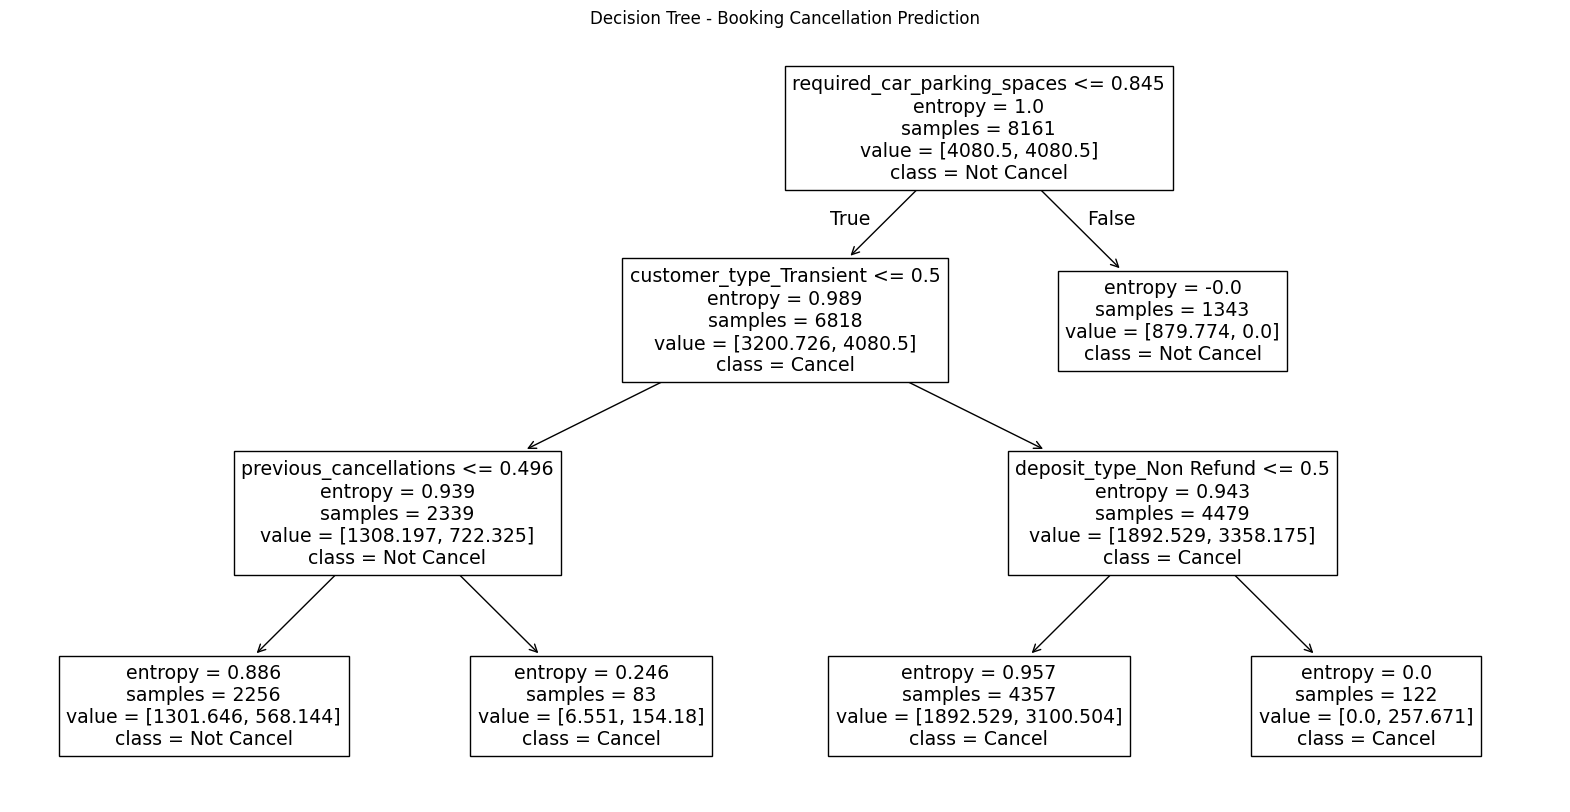

In [ ]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=X.columns, class_names=['Not Cancel','Cancel'], )
plt.title("Decision Tree - Booking Cancellation Prediction")

plt.show()

In [ ]:
# prediksi decision tree
y_pred_dt = dt_model.predict(X_test)

In [ ]:
# evaluasi decision tree
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.92      0.51      0.66      1559
           1       0.35      0.86      0.50       482

    accuracy                           0.59      2041
   macro avg       0.64      0.68      0.58      2041
weighted avg       0.79      0.59      0.62      2041



In [ ]:
accuracy_score(y_test, y_pred_dt)

0.5933365997060265

In [ ]:
# buat random forest
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=1000, max_depth = 5, criterion='gini')

In [ ]:
# training random forest
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=1000,
                       random_state=42)

In [ ]:
individual_tree = rf_model.estimators_[0]

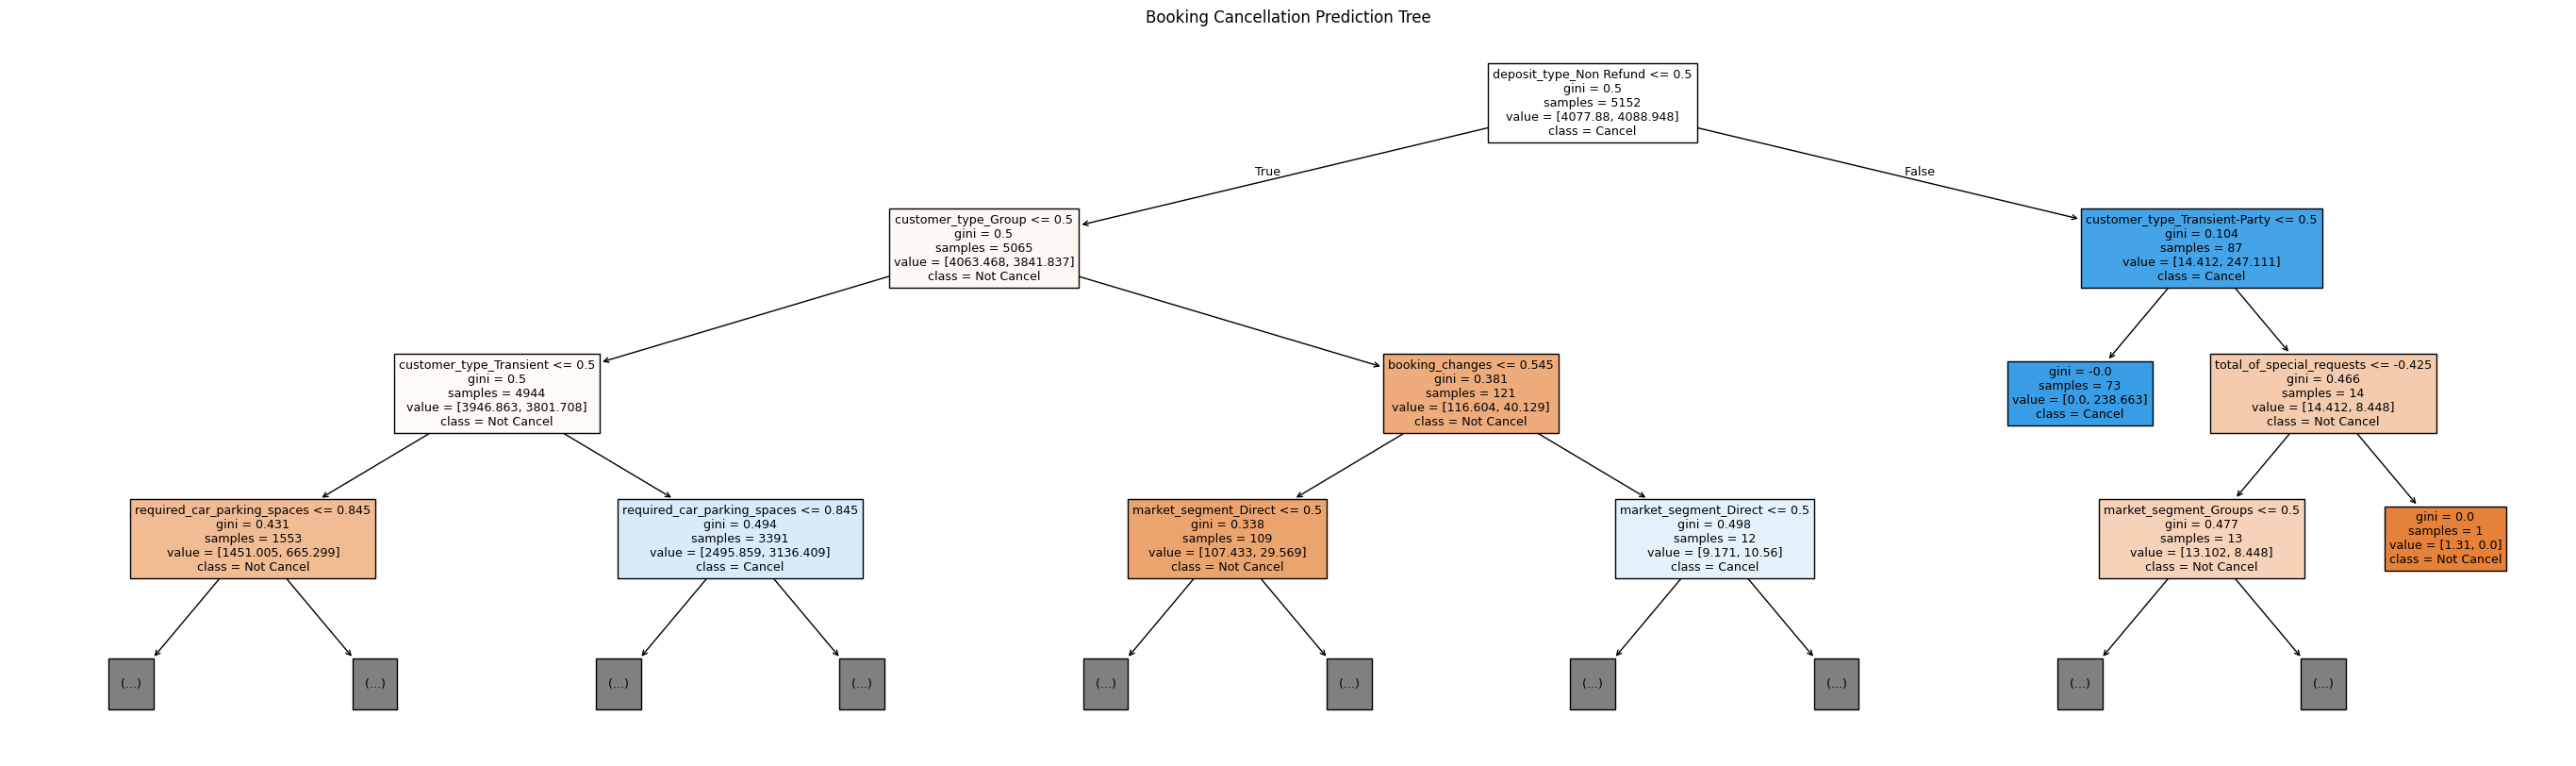

In [ ]:
plt.figure(figsize=(35,10))
tree.plot_tree(individual_tree, feature_names=X.columns, class_names=['Not Cancel','Cancel'], filled=True, max_depth=3)
plt.title("Booking Cancellation Prediction Tree")
plt.show()

In [ ]:
# prediksi random forest
y_pred_rf = rf_model.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred_rf)

array([[1054,  505],
       [ 103,  379]])

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.7021068103870651

In [ ]:
f1_score(y_test, y_pred_rf)

0.554904831625183

In [ ]:
# evaluasi random forest
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1559
           1       0.43      0.79      0.55       482

    accuracy                           0.70      2041
   macro avg       0.67      0.73      0.67      2041
weighted avg       0.80      0.70      0.72      2041



In [ ]:
# bandingin accuracy semua model

log_acc = accuracy_score(y_test, y_pred_log)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic:", log_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

Logistic: 0.6785889269965704
Decision Tree: 0.5933365997060265
Random Forest: 0.7021068103870651


## Model Comparison

Dalam project ini dilakukan beberapa eksperimen model untuk memprediksi booking cancellation, dimulai dari baseline model hingga model yang telah dioptimasi melalui penanganan class imbalance dan hyperparameter tuning.

Berikut merupakan perbandingan performa baseline model:

### Baseline Model Performance

| Model | Accuracy | Recall (Cancel) | F1 Score (Cancel) |
|-------|----------|-----------------|-------------------|
| Logistic Regression | 0.79 | 0.25 | 0.36 |
| Decision Tree | 0.68 | 0.26 | 0.28 |
| Random Forest | 0.70 | 0.29 | 0.31 |

Dari baseline model terlihat bahwa Logistic Regression memiliki accuracy tertinggi, namun kemampuan mendeteksi booking cancellation masih rendah karena recall masih kecil.

Selanjutnya dilakukan improvement dengan menangani class imbalance menggunakan class_weight serta melakukan hyperparameter tuning.

### Improved Model Performance

| Model | Accuracy | Recall (Cancel) | F1 Score (Cancel) |
|-------|----------|-----------------|-------------------|
| Logistic Regression (balanced) | 0.68 | 0.80 | 0.54 |
| Decision Tree (tuned) | 0.59 | 0.86 | 0.50 |
| Random Forest (balanced) | 0.70 | 0.79 | 0.55 |

Setelah dilakukan improvement, performa model dalam mendeteksi booking cancellation meningkat secara signifikan terutama pada recall cancellation.

Hal ini menunjukkan bahwa penanganan class imbalance memiliki pengaruh besar terhadap kemampuan model dalam mendeteksi booking yang berpotensi cancel.

Dari hasil perbandingan tersebut terlihat bahwa Random Forest memberikan performa paling seimbang antara accuracy dan kemampuan deteksi cancellation dibanding model lainnya.

In [ ]:
# ambil feature importance dari logistic regression

importance = pd.Series(log_model.coef_[0], index=X.columns)

importance

,0
previous_cancellations,0.486142
booking_changes,-0.188363
days_in_waiting_list,0.104922
required_car_parking_spaces,-3.073776
total_of_special_requests,-0.314227
market_segment_Complementary,0.067122
market_segment_Corporate,-0.122433
market_segment_Direct,0.538361
market_segment_Groups,-0.356746
market_segment_Offline TA/TO,-0.075890


In [ ]:
# urutkan pengaruh feature

importance_sorted = importance.sort_values(ascending=False)

importance_sorted

,0
deposit_type_Non Refund,3.117078
reserved_room_type_P,1.474887
market_segment_Online TA,1.258859
customer_type_Transient,0.900792
deposit_type_Refundable,0.868328
market_segment_Direct,0.538361
previous_cancellations,0.486142
reserved_room_type_B,0.469449
reserved_room_type_L,0.205001
reserved_room_type_C,0.197943


In [ ]:
# top 10 feature paling berpengaruh

importance_sorted.head(10)

,0
deposit_type_Non Refund,3.117078
reserved_room_type_P,1.474887
market_segment_Online TA,1.258859
customer_type_Transient,0.900792
deposit_type_Refundable,0.868328
market_segment_Direct,0.538361
previous_cancellations,0.486142
reserved_room_type_B,0.469449
reserved_room_type_L,0.205001
reserved_room_type_C,0.197943


In [ ]:
# feature yang menurunkan kemungkinan cancel

importance.sort_values().head(10)

,0
required_car_parking_spaces,-3.073776
customer_type_Group,-0.482037
market_segment_Groups,-0.356746
total_of_special_requests,-0.314227
booking_changes,-0.188363
market_segment_Corporate,-0.122433
market_segment_Offline TA/TO,-0.075890
reserved_room_type_F,-0.050870
customer_type_Transient-Party,-0.016600
reserved_room_type_G,-0.008093


In [ ]:
# buat confusion matrix
cm = confusion_matrix(y_test,y_pred_rf)

cm

array([[1054,  505],
       [ 103,  379]])

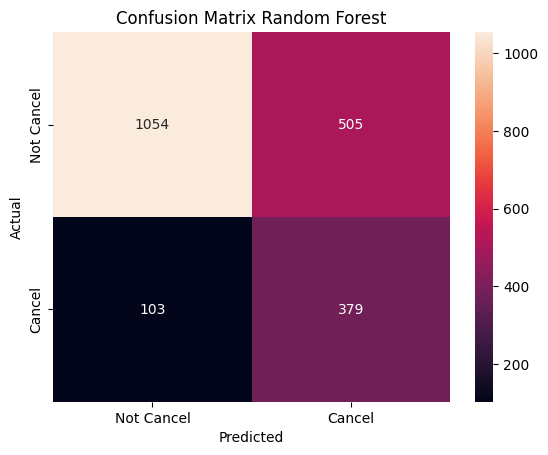

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)

sns.heatmap(cm,annot=True,fmt='d', xticklabels=['Not Cancel','Cancel'], yticklabels=['Not Cancel','Cancel'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Random Forest")
plt.show()

In [ ]:
# top 10 feature paling penting

top_features = importance_sorted.head(10)

top_features

,0
deposit_type_Non Refund,3.117078
reserved_room_type_P,1.474887
market_segment_Online TA,1.258859
customer_type_Transient,0.900792
deposit_type_Refundable,0.868328
market_segment_Direct,0.538361
previous_cancellations,0.486142
reserved_room_type_B,0.469449
reserved_room_type_L,0.205001
reserved_room_type_C,0.197943


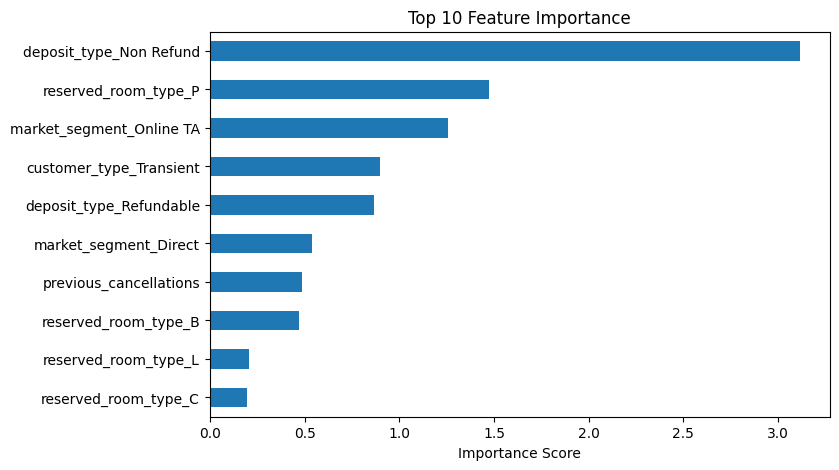

In [ ]:
# plot feature importance

plt.figure(figsize=(8,5))

top_features.sort_values().plot(kind='barh')

plt.title("Top 10 Feature Importance")

plt.xlabel("Importance Score")

plt.show()

## Final Model Selection

Berdasarkan hasil eksperimen beberapa algoritma machine learning yang telah dilakukan, yaitu Logistic Regression, Decision Tree, dan Random Forest, serta setelah dilakukan penanganan class imbalance dan hyperparameter tuning, model terbaik yang dipilih sebagai final model adalah **Random Forest Classifier dengan parameter class_weight='balanced'**.

Pemilihan model dilakukan berdasarkan beberapa evaluation metrics yaitu accuracy, recall, dan F1-score dengan mempertimbangkan kebutuhan bisnis hotel dalam mendeteksi booking cancellation.

Perbandingan performa model:

| Model | Accuracy | Recall (Cancel) | F1 Score (Cancel) |
|-------|----------|-----------------|-------------------|
| Logistic Regression | 0.68 | 0.80 | 0.54 |
| Decision Tree | 0.59 | 0.86 | 0.50 |
| Random Forest | 0.70 | 0.79 | 0.55 |

Decision Tree memiliki recall tertinggi, namun accuracy yang rendah menunjukkan model terlalu agresif dalam memprediksi cancellation sehingga berpotensi menghasilkan banyak false prediction.

Logistic Regression memiliki performa yang cukup stabil, namun memiliki keterbatasan dalam menangkap pola kompleks dibandingkan model berbasis tree.

Random Forest dipilih sebagai final model karena memberikan keseimbangan terbaik antara accuracy, recall, dan F1-score. Model ini mampu mendeteksi sebagian besar booking yang berpotensi cancel tanpa menurunkan accuracy secara signifikan.

Dalam konteks bisnis hotel, kemampuan mendeteksi cancellation sangat penting karena dapat membantu hotel mengurangi potensi kerugian akibat kamar kosong. Oleh karena itu model Random Forest dianggap memberikan trade-off terbaik antara performa model dan kebutuhan bisnis.

Dengan demikian, Random Forest dipilih sebagai final model untuk digunakan dalam prediksi booking cancellation.

## Conclusion

Berdasarkan hasil eksperimen beberapa algoritma machine learning serta hyperparameter tuning yang telah dilakukan, model terbaik dalam project ini adalah **Random Forest Classifier dengan parameter class_weight='balanced'**.

Setelah dilakukan penanganan class imbalance serta tuning parameter, performa model dalam mendeteksi booking cancellation mengalami peningkatan yang signifikan.

Perbandingan performa model:

Logistic Regression (balanced):
Accuracy : 0.68  
Recall cancellation : 0.80  
F1-score cancellation : 0.54  

Decision Tree (tuned):
Accuracy : 0.59  
Recall cancellation : 0.86  
F1-score cancellation : 0.50  

Random Forest (balanced):
Accuracy : 0.70  
Recall cancellation : 0.79  
F1-score cancellation : 0.55  

Walaupun Decision Tree memiliki recall tertinggi, model tersebut memiliki accuracy yang cukup rendah sehingga berpotensi menghasilkan terlalu banyak false prediction. Oleh karena itu Random Forest dipilih karena memberikan keseimbangan terbaik antara kemampuan mendeteksi cancellation dan kestabilan akurasi model.

Model Random Forest mampu mendeteksi sekitar **79% booking yang berpotensi dibatalkan**, sehingga model ini dapat membantu hotel dalam mengidentifikasi risiko cancellation lebih awal.

Berdasarkan hasil analisis feature importance, faktor utama yang mempengaruhi kemungkinan booking cancellation adalah:

- Previous cancellations (riwayat pembatalan sebelumnya)
- Deposit type
- Days in waiting list
- Market segment
- Customer type
- Booking behaviour customer

Hal ini menunjukkan bahwa perilaku historis customer serta karakteristik reservasi merupakan faktor penting dalam menentukan kemungkinan pembatalan booking.

Model ini dapat digunakan sebagai alat pendukung keputusan (decision support system) untuk membantu hotel dalam mengelola risiko pembatalan reservasi.

## Recommendation

Berdasarkan hasil modeling dan analisis yang telah dilakukan, terdapat beberapa rekomendasi bisnis yang dapat diterapkan oleh pihak hotel:

1. Hotel dapat menerapkan kebijakan deposit kepada customer dengan riwayat pembatalan tinggi karena previous cancellations terbukti menjadi faktor penting dalam prediksi cancellation.

2. Hotel dapat menggunakan model ini sebagai early warning system untuk mendeteksi booking dengan risiko cancellation tinggi sehingga hotel dapat melakukan strategi overbooking secara lebih terukur.

3. Hotel dapat melakukan monitoring terhadap booking dari market segment tertentu yang memiliki kecenderungan cancellation lebih tinggi.

4. Hotel dapat memberikan insentif tambahan kepada customer dengan tingkat komitmen tinggi seperti customer dengan special requests atau kebutuhan parking space.

5. Hotel dapat menggunakan hasil prediksi model sebagai bahan pertimbangan dalam menentukan kebijakan reservasi seperti refund policy atau confirmation policy.

6. Untuk peningkatan model di masa depan, hotel dapat mempertimbangkan penambahan data tambahan seperti:
   - Lead time booking
   - Harga kamar
   - Durasi menginap
   - Seasonal demand
   - Customer loyalty data

7. Model juga dapat ditingkatkan dengan melakukan retraining secara berkala agar tetap relevan terhadap perubahan behaviour customer.

Dengan implementasi model ini, hotel diharapkan dapat mengurangi potensi kerugian akibat booking cancellation serta meningkatkan efisiensi dalam pengelolaan reservasi hotel.